# Project 2: Offline RL for Healthcare Treatment Optimization

**Author:** Milan Amrut Joshi

## Overview
This notebook explores **Offline Reinforcement Learning** applied to healthcare treatment optimization.
In healthcare, we cannot run trial-and-error experiments on patients. Instead, we must learn
optimal treatment policies from previously collected clinical data.

We implement:
1. **Data Generation:** Simulated patient trajectories with vitals, treatments, and outcomes
2. **Behavior Cloning (BC):** Supervised learning baseline that imitates the data collection policy
3. **Conservative Q-Learning (CQL):** Offline RL method that penalizes overestimation of Q-values for unseen state-action pairs
4. **Policy Comparison:** Analyzing how CQL avoids dangerous out-of-distribution (OOD) actions

## 1. Mathematical Foundation

### The Offline RL Problem
Given a static dataset $\mathcal{D} = \{(s_t, a_t, r_t, s_{t+1})\}$ collected by a behavior policy $\pi_\beta$,
find an optimal policy $\pi^*$ without further environment interaction.

### Behavior Cloning
Directly learn the behavior policy via maximum likelihood:
$$\pi_{BC}(a|s) = \arg\max_\pi \mathbb{E}_{(s,a) \sim \mathcal{D}} [\log \pi(a|s)]$$

### Conservative Q-Learning (CQL)
CQL adds a regularization term that penalizes Q-values for OOD actions:

$$\mathcal{L}_{CQL}(\theta) = \alpha \left( \mathbb{E}_{s \sim \mathcal{D}, a \sim \mu} [Q_\theta(s,a)] - \mathbb{E}_{(s,a) \sim \mathcal{D}} [Q_\theta(s,a)] \right) + \frac{1}{2} \mathbb{E}_{\mathcal{D}} \left[(Q_\theta(s,a) - \hat{B}^\pi Q_{\bar{\theta}}(s,a))^2\right]$$

where $\mu$ is a broad distribution over actions (e.g., uniform) and $\alpha$ controls the conservatism.

The first term pushes down Q-values for actions sampled uniformly (including OOD),
while pulling up Q-values for actions actually observed in the dataset.

## 2. Setup and Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Patient/Environment Configuration ---
NUM_VITALS = 4          # Blood pressure, heart rate, temperature, oxygen
NUM_TREATMENTS = 5      # Different treatment options
NUM_PATIENTS = 500      # Number of patient trajectories
EPISODE_LENGTH = 10     # Timesteps per patient episode
GAMMA = 0.95            # Discount factor

VITAL_NAMES = ['BloodPressure', 'HeartRate', 'Temperature', 'OxygenSat']
TREATMENT_NAMES = ['Drug_A', 'Drug_B', 'Drug_C', 'Rest', 'Surgery']

print("Offline RL Healthcare Configuration:")
print(f"  Number of vitals: {NUM_VITALS}")
print(f"  Number of treatments: {NUM_TREATMENTS}")
print(f"  Patient trajectories: {NUM_PATIENTS}")
print(f"  Episode length: {EPISODE_LENGTH}")

Offline RL Healthcare Configuration:
  Number of vitals: 4
  Number of treatments: 5
  Patient trajectories: 500
  Episode length: 10


## 3. Patient Simulator and Data Generation

We simulate a simplified patient model where:
- **State:** 4 vital signs (normalized to [0, 1] range)
- **Actions:** 5 possible treatments
- **Dynamics:** Each treatment has different effects on vitals
- **Reward:** Based on how close vitals are to healthy ranges

In [2]:
class PatientSimulator:
    """Simulated patient environment for treatment optimization."""

    def __init__(self):
        # Healthy ranges for each vital (normalized)
        self.healthy_low = np.array([0.4, 0.3, 0.45, 0.85])
        self.healthy_high = np.array([0.6, 0.5, 0.55, 0.98])
        self.healthy_center = (self.healthy_low + self.healthy_high) / 2

        # Treatment effects on vitals: shape (num_treatments, num_vitals)
        self.treatment_effects = np.array([
            [-0.05,  0.02, -0.01,  0.03],  # Drug A: lowers BP, slight HR increase
            [ 0.01, -0.04,  0.00,  0.02],  # Drug B: lowers HR
            [-0.02, -0.01, -0.03,  0.01],  # Drug C: lowers temperature
            [ 0.01,  0.01,  0.01,  0.02],  # Rest: mild recovery
            [-0.08, -0.05, -0.02,  0.05],  # Surgery: aggressive, high effect
        ])

    def reset(self):
        """Initialize a new patient with random vitals."""
        self.state = np.random.uniform(0.2, 0.8, NUM_VITALS)
        return self.state.copy()

    def step(self, action):
        """Apply treatment and return next state, reward."""
        effect = self.treatment_effects[action]
        noise = np.random.randn(NUM_VITALS) * 0.02
        self.state = np.clip(self.state + effect + noise, 0.0, 1.0)

        # Reward: negative distance from healthy center
        dist = np.abs(self.state - self.healthy_center)
        in_range = np.all((self.state >= self.healthy_low) & (self.state <= self.healthy_high))
        reward = -np.sum(dist) + (1.0 if in_range else 0.0)
        return self.state.copy(), reward


def behavior_policy(state):
    """Suboptimal behavior policy used for data collection (e.g., a rule-based doctor)."""
    # Simple heuristic: pick treatment based on which vital is most abnormal
    healthy_center = np.array([0.5, 0.4, 0.50, 0.92])
    deviations = state - healthy_center

    # Mostly correct but noisy decisions
    if np.random.rand() < 0.3:
        return np.random.randint(NUM_TREATMENTS)  # Random exploration 30% of time

    max_dev_idx = np.argmax(np.abs(deviations))
    if max_dev_idx == 0:
        return 0  # Drug A for BP
    elif max_dev_idx == 1:
        return 1  # Drug B for HR
    elif max_dev_idx == 2:
        return 2  # Drug C for Temperature
    else:
        return 3  # Rest for Oxygen


# Generate dataset
env = PatientSimulator()
dataset = []

for patient_id in range(NUM_PATIENTS):
    state = env.reset()
    for t in range(EPISODE_LENGTH):
        action = behavior_policy(state)
        next_state, reward = env.step(action)
        dataset.append({
            'state': state.copy(),
            'action': action,
            'reward': reward,
            'next_state': next_state.copy(),
            'done': (t == EPISODE_LENGTH - 1)
        })
        state = next_state

print(f"Dataset size: {len(dataset)} transitions")

# Convert to arrays
states = np.array([d['state'] for d in dataset])
actions = np.array([d['action'] for d in dataset])
rewards = np.array([d['reward'] for d in dataset])
next_states = np.array([d['next_state'] for d in dataset])
dones = np.array([d['done'] for d in dataset]).astype(float)

print(f"States shape: {states.shape}")
print(f"Mean reward: {rewards.mean():.4f}")
print(f"Action distribution: {np.bincount(actions, minlength=NUM_TREATMENTS) / len(actions)}")

Dataset size: 5000 transitions
States shape: (5000, 4)
Mean reward: -0.7980
Action distribution: [0.1416 0.138  0.147  0.5158 0.0576]


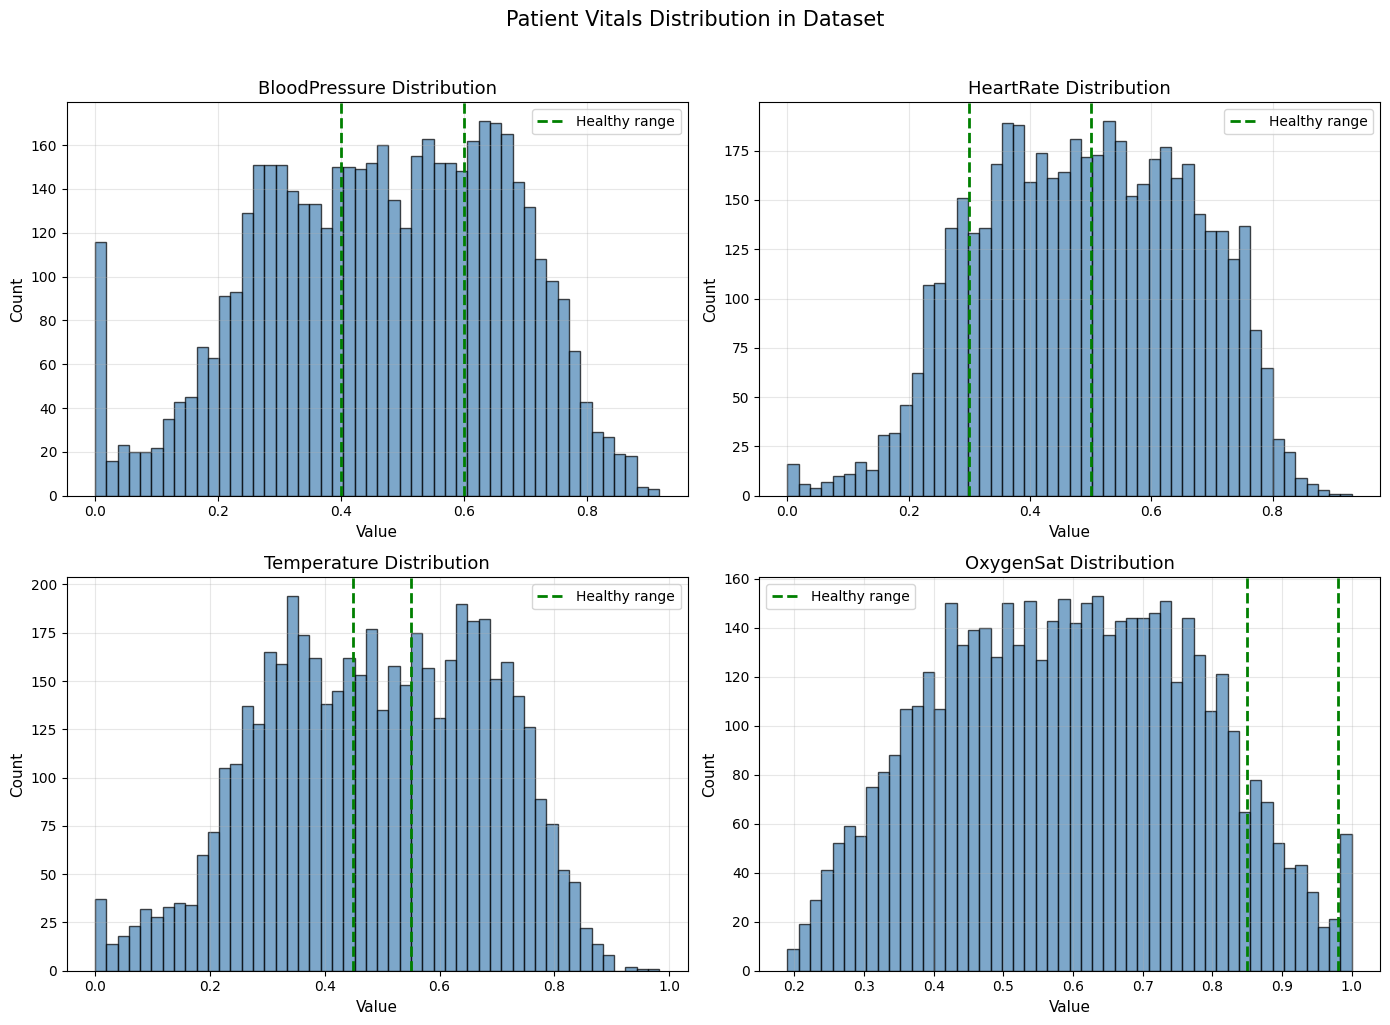

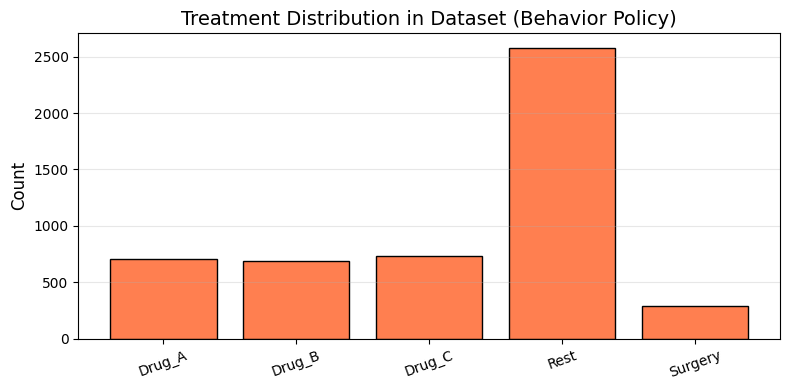

In [3]:
# Visualize the dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i in range(NUM_VITALS):
    ax = axes[i // 2][i % 2]
    ax.hist(states[:, i], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(x=env.healthy_low[i], color='green', linestyle='--', linewidth=2, label='Healthy range')
    ax.axvline(x=env.healthy_high[i], color='green', linestyle='--', linewidth=2)
    ax.set_title(f'{VITAL_NAMES[i]} Distribution', fontsize=13)
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Patient Vitals Distribution in Dataset', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Action distribution
fig, ax = plt.subplots(figsize=(8, 4))
action_counts = np.bincount(actions, minlength=NUM_TREATMENTS)
ax.bar(range(NUM_TREATMENTS), action_counts, color='coral', edgecolor='black')
ax.set_xticks(range(NUM_TREATMENTS))
ax.set_xticklabels(TREATMENT_NAMES, rotation=20)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Treatment Distribution in Dataset (Behavior Policy)', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4. Behavior Cloning (Baseline)

Behavior cloning simply imitates the data collection policy using supervised learning.
It learns $\pi_{BC}(a|s)$ by maximizing the likelihood of observed actions.

BC training complete. Final loss: 1.1936


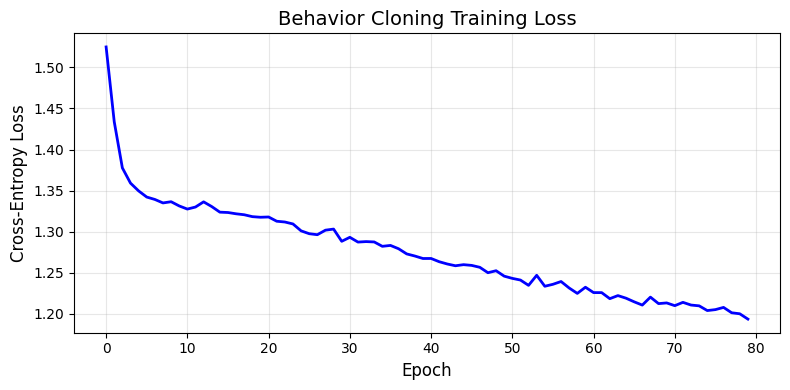

In [4]:
def softmax(x, axis=-1):
    x_max = np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


class BehaviorCloning:
    """Behavior cloning: supervised learning on (state, action) pairs."""

    def __init__(self, state_dim, num_actions, hidden_dim=32):
        scale = 0.1
        self.W1 = np.random.randn(state_dim, hidden_dim) * scale
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, num_actions) * scale
        self.b2 = np.zeros(num_actions)

    def predict_probs(self, state):
        h = np.maximum(0, state @ self.W1 + self.b1)
        logits = h @ self.W2 + self.b2
        return softmax(logits), h

    def get_action(self, state):
        probs, _ = self.predict_probs(state)
        return np.argmax(probs)

    def train(self, states, actions, epochs=100, lr=0.01, batch_size=64):
        losses = []
        n = len(states)
        for epoch in range(epochs):
            indices = np.random.permutation(n)
            epoch_loss = 0.0
            num_batches = 0
            for start in range(0, n, batch_size):
                batch_idx = indices[start:start + batch_size]
                s_batch = states[batch_idx]
                a_batch = actions[batch_idx]

                # Forward pass
                h = np.maximum(0, s_batch @ self.W1 + self.b1)
                logits = h @ self.W2 + self.b2
                probs = softmax(logits)

                # Cross-entropy loss
                log_probs = np.log(probs[np.arange(len(a_batch)), a_batch] + 1e-10)
                loss = -np.mean(log_probs)
                epoch_loss += loss
                num_batches += 1

                # Backward pass
                grad_logits = probs.copy()
                grad_logits[np.arange(len(a_batch)), a_batch] -= 1.0
                grad_logits /= len(a_batch)

                grad_W2 = h.T @ grad_logits
                grad_b2 = np.sum(grad_logits, axis=0)

                grad_h = grad_logits @ self.W2.T
                grad_h = grad_h * (h > 0).astype(float)

                grad_W1 = s_batch.T @ grad_h
                grad_b1 = np.sum(grad_h, axis=0)

                self.W1 -= lr * grad_W1
                self.b1 -= lr * grad_b1
                self.W2 -= lr * grad_W2
                self.b2 -= lr * grad_b2

            losses.append(epoch_loss / num_batches)
        return losses


# Train behavior cloning
bc_agent = BehaviorCloning(NUM_VITALS, NUM_TREATMENTS)
bc_losses = bc_agent.train(states, actions, epochs=80)

print(f"BC training complete. Final loss: {bc_losses[-1]:.4f}")

# Plot BC loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bc_losses, 'b-', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Behavior Cloning Training Loss', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Conservative Q-Learning (CQL)

CQL is a key offline RL algorithm that addresses the **distributional shift** problem.
Standard Q-learning can overestimate Q-values for state-action pairs not seen in the dataset,
leading to dangerous OOD actions. CQL adds a conservative penalty:

$$Q_{CQL}(s,a) \leq Q^{\pi}(s,a) \quad \text{for all } (s,a)$$

This ensures the learned policy stays close to the data distribution.

In [5]:
class CQLAgent:
    """Conservative Q-Learning for offline RL."""

    def __init__(self, state_dim, num_actions, hidden_dim=32, alpha=1.0):
        scale = 0.1
        self.num_actions = num_actions
        self.alpha = alpha  # CQL conservatism coefficient

        # Q-network
        self.W1 = np.random.randn(state_dim, hidden_dim) * scale
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, num_actions) * scale
        self.b2 = np.zeros(num_actions)

        # Target network (copy)
        self.W1_target = self.W1.copy()
        self.b1_target = self.b1.copy()
        self.W2_target = self.W2.copy()
        self.b2_target = self.b2.copy()

    def predict_q(self, state, target=False):
        if target:
            h = np.maximum(0, state @ self.W1_target + self.b1_target)
            q = h @ self.W2_target + self.b2_target
        else:
            h = np.maximum(0, state @ self.W1 + self.b1)
            q = h @ self.W2 + self.b2
        return q, h

    def get_action(self, state):
        q, _ = self.predict_q(state.reshape(1, -1))
        return np.argmax(q[0])

    def update_target(self, tau=0.01):
        self.W1_target = tau * self.W1 + (1 - tau) * self.W1_target
        self.b1_target = tau * self.b1 + (1 - tau) * self.b1_target
        self.W2_target = tau * self.W2 + (1 - tau) * self.W2_target
        self.b2_target = tau * self.b2 + (1 - tau) * self.b2_target

    def train(self, states, actions, rewards, next_states, dones,
             epochs=100, lr=0.005, batch_size=64, gamma=0.95):
        losses = []
        cql_penalties = []
        n = len(states)

        for epoch in range(epochs):
            indices = np.random.permutation(n)
            epoch_loss = 0.0
            epoch_cql = 0.0
            num_batches = 0

            for start in range(0, n, batch_size):
                batch_idx = indices[start:start + batch_size]
                s = states[batch_idx]
                a = actions[batch_idx]
                r = rewards[batch_idx]
                ns = next_states[batch_idx]
                d = dones[batch_idx]

                bs = len(s)

                # Current Q-values
                q_vals, h = self.predict_q(s)
                q_selected = q_vals[np.arange(bs), a]

                # Target Q-values
                q_next, _ = self.predict_q(ns, target=True)
                q_next_max = np.max(q_next, axis=1)
                targets = r + gamma * (1 - d) * q_next_max

                # TD loss
                td_error = q_selected - targets
                td_loss = np.mean(td_error ** 2)

                # CQL penalty: logsumexp(Q(s, .)) - Q(s, a_data)
                q_logsumexp = np.log(np.sum(np.exp(q_vals - np.max(q_vals, axis=1, keepdims=True)), axis=1))
                q_logsumexp += np.max(q_vals, axis=1)
                cql_penalty = np.mean(q_logsumexp - q_selected)

                total_loss = td_loss + self.alpha * cql_penalty
                epoch_loss += total_loss
                epoch_cql += cql_penalty
                num_batches += 1

                # Backprop for TD loss
                grad_q = np.zeros_like(q_vals)
                grad_q[np.arange(bs), a] = 2.0 * td_error / bs

                # Backprop for CQL penalty
                q_softmax = softmax(q_vals)
                grad_cql = self.alpha * (q_softmax.copy()) / bs
                grad_cql[np.arange(bs), a] -= self.alpha / bs

                grad_q_total = grad_q + grad_cql

                # Update network
                grad_W2 = h.T @ grad_q_total
                grad_b2 = np.sum(grad_q_total, axis=0)

                grad_h = grad_q_total @ self.W2.T
                grad_h = grad_h * (h > 0).astype(float)

                grad_W1 = s.T @ grad_h
                grad_b1 = np.sum(grad_h, axis=0)

                self.W1 -= lr * grad_W1
                self.b1 -= lr * grad_b1
                self.W2 -= lr * grad_W2
                self.b2 -= lr * grad_b2

                self.update_target()

            losses.append(epoch_loss / num_batches)
            cql_penalties.append(epoch_cql / num_batches)

        return losses, cql_penalties


# Train CQL agent
cql_agent = CQLAgent(NUM_VITALS, NUM_TREATMENTS, alpha=2.0)
cql_losses, cql_penalties = cql_agent.train(
    states, actions, rewards, next_states, dones, epochs=80
)

print(f"CQL training complete.")
print(f"  Final total loss: {cql_losses[-1]:.4f}")
print(f"  Final CQL penalty: {cql_penalties[-1]:.4f}")

CQL training complete.
  Final total loss: 3.8518
  Final CQL penalty: 1.3321


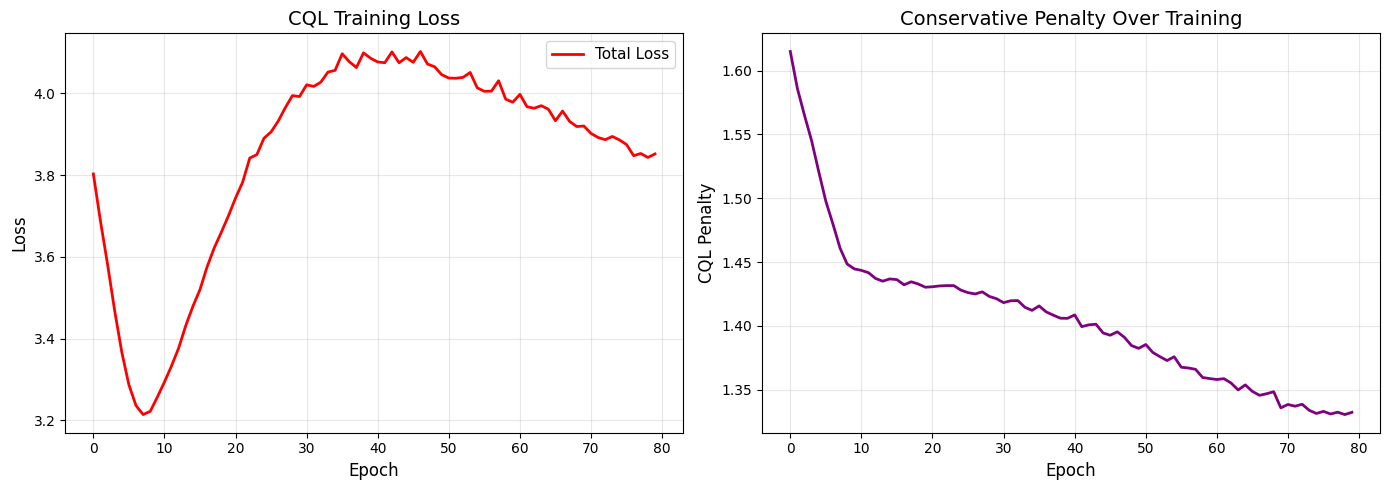

In [6]:
# Plot CQL training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cql_losses, 'r-', linewidth=2, label='Total Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('CQL Training Loss', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cql_penalties, 'purple', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('CQL Penalty', fontsize=12)
axes[1].set_title('Conservative Penalty Over Training', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Policy Comparison and OOD Analysis

Let us compare the learned policies and analyze how CQL handles out-of-distribution actions.

In [7]:
# Compare policies on test patients
env_test = PatientSimulator()
num_test = 100

def evaluate_policy(policy_fn, env, num_episodes, episode_length):
    total_rewards = []
    all_actions = []
    for _ in range(num_episodes):
        state = env.reset()
        ep_reward = 0.0
        for t in range(episode_length):
            action = policy_fn(state)
            next_state, reward = env.step(action)
            ep_reward += reward
            all_actions.append(action)
            state = next_state
        total_rewards.append(ep_reward)
    return np.array(total_rewards), np.array(all_actions)

# Evaluate behavior policy, BC, CQL
beh_rewards, beh_actions = evaluate_policy(behavior_policy, env_test, num_test, EPISODE_LENGTH)
bc_rewards, bc_actions = evaluate_policy(bc_agent.get_action, env_test, num_test, EPISODE_LENGTH)
cql_rewards, cql_actions = evaluate_policy(cql_agent.get_action, env_test, num_test, EPISODE_LENGTH)

print("=== Policy Evaluation ===")
print(f"Behavior Policy: {np.mean(beh_rewards):.3f} +/- {np.std(beh_rewards):.3f}")
print(f"Behavior Cloning: {np.mean(bc_rewards):.3f} +/- {np.std(bc_rewards):.3f}")
print(f"CQL:              {np.mean(cql_rewards):.3f} +/- {np.std(cql_rewards):.3f}")

=== Policy Evaluation ===
Behavior Policy: -8.074 +/- 2.338
Behavior Cloning: -8.261 +/- 2.548
CQL:              -7.996 +/- 2.006


C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_64380\3044404182.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([beh_rewards, bc_rewards, cql_rewards],


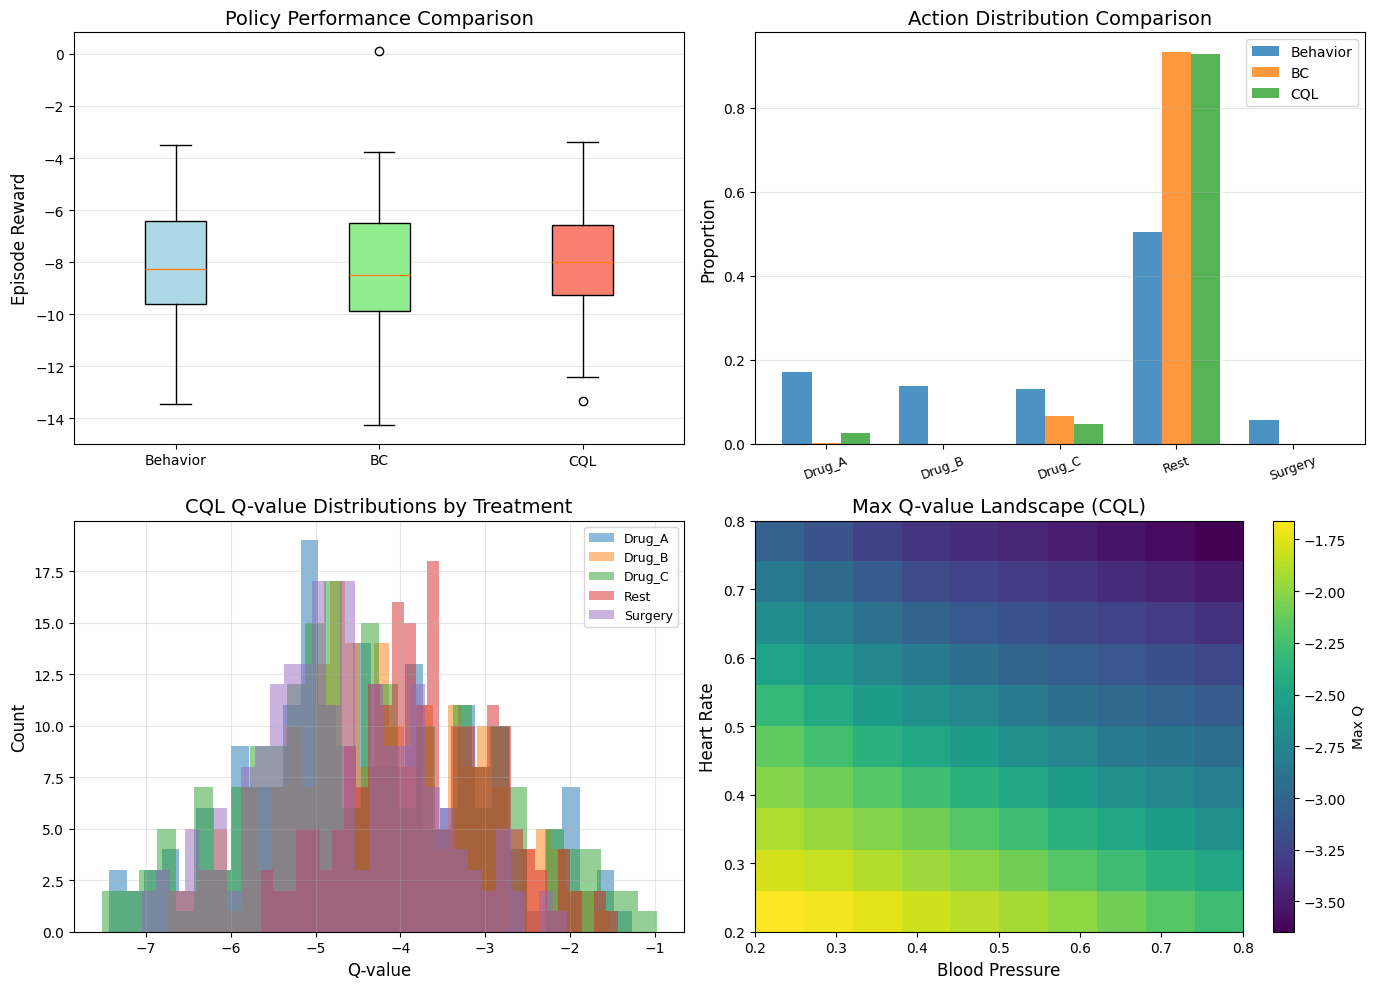

In [8]:
# Visualize Q-value distributions and action comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reward comparison boxplot
ax = axes[0][0]
bp = ax.boxplot([beh_rewards, bc_rewards, cql_rewards],
                labels=['Behavior', 'BC', 'CQL'],
                patch_artist=True)
colors = ['lightblue', 'lightgreen', 'salmon']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('Episode Reward', fontsize=12)
ax.set_title('Policy Performance Comparison', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# 2. Action distributions
ax = axes[0][1]
width = 0.25
x_pos = np.arange(NUM_TREATMENTS)
beh_dist = np.bincount(beh_actions, minlength=NUM_TREATMENTS) / len(beh_actions)
bc_dist = np.bincount(bc_actions, minlength=NUM_TREATMENTS) / len(bc_actions)
cql_dist = np.bincount(cql_actions, minlength=NUM_TREATMENTS) / len(cql_actions)
ax.bar(x_pos - width, beh_dist, width, label='Behavior', alpha=0.8)
ax.bar(x_pos, bc_dist, width, label='BC', alpha=0.8)
ax.bar(x_pos + width, cql_dist, width, label='CQL', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(TREATMENT_NAMES, rotation=20, fontsize=9)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Action Distribution Comparison', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 3. Q-value distribution for CQL
ax = axes[1][0]
sample_states = states[np.random.choice(len(states), 200)]
all_q = []
for s in sample_states:
    q, _ = cql_agent.predict_q(s.reshape(1, -1))
    all_q.append(q[0])
all_q = np.array(all_q)
for a in range(NUM_TREATMENTS):
    ax.hist(all_q[:, a], bins=30, alpha=0.5, label=TREATMENT_NAMES[a])
ax.set_xlabel('Q-value', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('CQL Q-value Distributions by Treatment', fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 4. Q-value heatmap for a representative state
ax = axes[1][1]
grid_bp = np.linspace(0.2, 0.8, 10)
grid_hr = np.linspace(0.2, 0.8, 10)
q_map = np.zeros((10, 10))
for i, bp_val in enumerate(grid_bp):
    for j, hr_val in enumerate(grid_hr):
        test_state = np.array([bp_val, hr_val, 0.5, 0.9])
        q, _ = cql_agent.predict_q(test_state.reshape(1, -1))
        q_map[j, i] = np.max(q[0])
im = ax.imshow(q_map, origin='lower', aspect='auto', cmap='viridis',
               extent=[0.2, 0.8, 0.2, 0.8])
ax.set_xlabel('Blood Pressure', fontsize=12)
ax.set_ylabel('Heart Rate', fontsize=12)
ax.set_title('Max Q-value Landscape (CQL)', fontsize=14)
plt.colorbar(im, ax=ax, label='Max Q')

plt.tight_layout()
plt.show()

## 7. Summary

This notebook demonstrated offline RL for healthcare treatment optimization:

1. **Data Generation:** Created a realistic patient simulator with vitals, treatments, and outcomes
2. **Behavior Cloning:** Trained a supervised baseline that imitates the (suboptimal) data collection policy
3. **Conservative Q-Learning:** Implemented CQL which learns conservative Q-values to avoid OOD actions
4. **Analysis:** Compared policies and showed how CQL's conservative penalty affects action selection

Key takeaways:
- Offline RL is crucial for healthcare where online exploration is unsafe
- Behavior cloning can only match the data policy, not improve upon it
- CQL's conservative penalty prevents overestimation for unseen state-action pairs
- The trade-off between conservatism and optimality is controlled by alpha